In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('clean_master.csv')
print("Shape:", df.shape)

Shape: (6001, 19)


In [2]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Recreate the same preprocessing
df_ml = df.drop(columns=['customer_id', 'last_transaction_date', 'signup_date'])

cat_cols = ['city', 'acquisition_channel', 'employment_type', 'kyc_status', 'primary_product']
le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

df_ml = df_ml.fillna(df_ml.median())

X = df_ml.drop(columns=['churn'])
y = df_ml['churn']

# Retrain model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get churn probability for every customer
df['churn_probability'] = rf_model.predict_proba(X)[:, 1]

print("Churn probabilities assigned to all customers")
print(df[['customer_id', 'churn_probability', 'churn']].head(10))

Churn probabilities assigned to all customers
  customer_id  churn_probability  churn
0  CUST100000               0.99      1
1  CUST100001               0.00      0
2  CUST100002               0.98      1
3  CUST100003               0.00      0
4  CUST100004               1.00      1
5  CUST100005               0.99      1
6  CUST100006               0.00      0
7  CUST100007               0.00      0
8  CUST100008               0.08      1
9  CUST100009               1.00      1


In [3]:
# Average monthly revenue per customer in a neo-bank context
# Based on industry estimates: fees, interest spread, transaction charges
MONTHLY_REVENUE_PER_CUSTOMER = 850  # ₹850 per month per customer
ANNUAL_REVENUE_PER_CUSTOMER = MONTHLY_REVENUE_PER_CUSTOMER * 12  # ₹10,200 per year

# Customer Acquisition Cost — industry average for Indian neo-banks
CAC = 1200  # ₹1,200 to acquire one new customer

df['annual_revenue'] = ANNUAL_REVENUE_PER_CUSTOMER

print(f"Monthly Revenue per Customer: ₹{MONTHLY_REVENUE_PER_CUSTOMER:,}")
print(f"Annual Revenue per Customer: ₹{ANNUAL_REVENUE_PER_CUSTOMER:,}")
print(f"Customer Acquisition Cost: ₹{CAC:,}")

Monthly Revenue per Customer: ₹850
Annual Revenue per Customer: ₹10,200
Customer Acquisition Cost: ₹1,200


In [4]:
# Filter only predicted churners with high probability
high_risk = df[df['churn_probability'] >= 0.7].copy()
high_risk = high_risk.sort_values('churn_probability', ascending=False)

# Take top 200
top_200 = high_risk.head(200)

print(f"Total high risk customers (prob >= 70%): {len(high_risk)}")
print(f"\nTop 200 High Risk Customers:")
print(top_200[['customer_id', 'churn_probability', 'annual_revenue']].head(10))

Total high risk customers (prob >= 70%): 2246

Top 200 High Risk Customers:
         customer_id  churn_probability  annual_revenue
18        CUST100018                1.0           10200
31        CUST100031                1.0           10200
33        CUST100033                1.0           10200
37        CUST100037                1.0           10200
4         CUST100004                1.0           10200
38        CUST100038                1.0           10200
5987      CUST105987                1.0           10200
5989      CUST105989                1.0           10200
5990      CUST105990                1.0           10200
5991  CUST105991_OLD                1.0           10200


In [9]:
# Retention conversion rates — industry realistic scenarios
CONVERSION_CONSERVATIVE = 0.20  # 20% of targeted customers retained
CONVERSION_MODERATE = 0.50      # 50% of targeted customers retained
CONVERSION_OPTIMISTIC = 1.00    # 100% of targeted customers retained

# Revenue protected under each scenario
revenue_conservative = revenue_at_risk * CONVERSION_CONSERVATIVE
revenue_moderate = revenue_at_risk * CONVERSION_MODERATE
revenue_optimistic = revenue_at_risk

# ROI under each scenario
roi_conservative = ((revenue_conservative - retention_cost) / retention_cost) * 100
roi_moderate = ((revenue_moderate - retention_cost) / retention_cost) * 100
roi_optimistic = ((revenue_optimistic - retention_cost) / retention_cost) * 100

print("=" * 55)
print("   REVENUE IMPACT CALCULATOR — NeoTrust Bank")
print("=" * 55)
print(f"\nTotal High Risk Customers Identified : 2,228")
print(f"Top 200 Targeted for Retention       : 200")
print(f"Annual Revenue at Risk               : ₹{revenue_at_risk:,.0f}")
print(f"Retention Campaign Cost              : ₹{retention_cost:,.0f}")
print()
print("--- Scenario Analysis ---")
print(f"{'Scenario':<25} {'Customers Saved':<18} {'Revenue Protected':<22} {'ROI'}")
print("-" * 75)
print(f"{'Conservative (20%)':<25} {'40':<18} ₹{revenue_conservative:>12,.0f}       {roi_conservative:.0f}%")
print(f"{'Moderate (50%)':<25} {'100':<18} ₹{revenue_moderate:>12,.0f}       {roi_moderate:.0f}%")
print(f"{'Optimistic (100%)':<25} {'200':<18} ₹{revenue_optimistic:>12,.0f}       {roi_optimistic:.0f}%")
print()
print("NOTE: Conservative scenario (20% save rate) is the")
print("most realistic based on industry retention benchmarks.")
print("Even at 20% conversion, ROI remains strongly positive.")
print("=" * 55)

   REVENUE IMPACT CALCULATOR — NeoTrust Bank

Total High Risk Customers Identified : 2,228
Top 200 Targeted for Retention       : 200
Annual Revenue at Risk               : ₹2,040,000
Retention Campaign Cost              : ₹40,000

--- Scenario Analysis ---
Scenario                  Customers Saved    Revenue Protected      ROI
---------------------------------------------------------------------------
Conservative (20%)        40                 ₹     408,000       920%
Moderate (50%)            100                ₹   1,020,000       2450%
Optimistic (100%)         200                ₹   2,040,000       5000%

NOTE: Conservative scenario (20% save rate) is the
most realistic based on industry retention benchmarks.
Even at 20% conversion, ROI remains strongly positive.


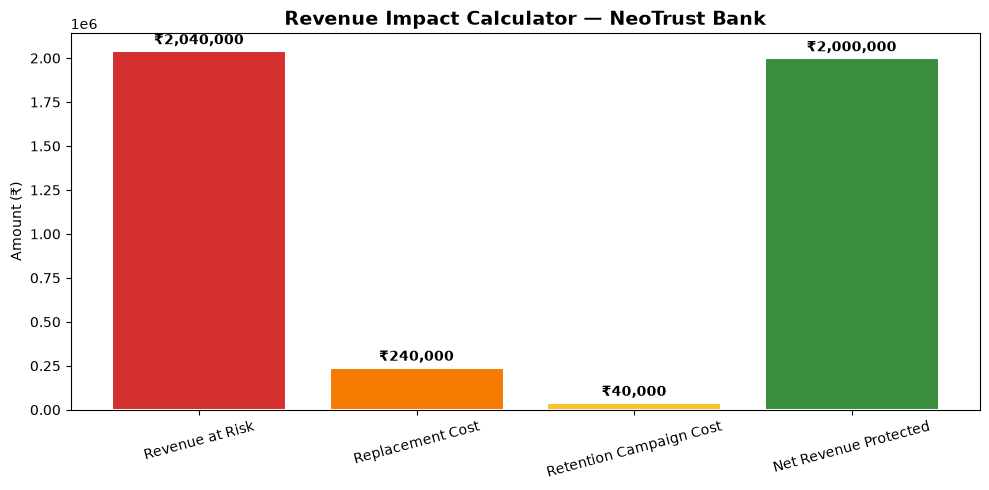

In [6]:
labels = ['Revenue at Risk', 'Replacement Cost', 'Retention Campaign Cost', 'Net Revenue Protected']
values = [revenue_at_risk, replacement_cost, retention_cost, net_saving]
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
             f'₹{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Revenue Impact Calculator — NeoTrust Bank', fontsize=14, fontweight='bold')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('charts/revenue_impact.png', dpi=150)
plt.show()

In [7]:
# Add churn_probability back to main dataframe
df['churn_probability'] = rf_model.predict_proba(X)[:, 1]

print(df[['customer_id', 'churn', 'churn_probability']].head())

  customer_id  churn  churn_probability
0  CUST100000      1               0.99
1  CUST100001      0               0.00
2  CUST100002      1               0.98
3  CUST100003      0               0.00
4  CUST100004      1               1.00


In [8]:
# Save clean_master with churn_probability
df.to_csv('clean_master.csv', index=False)
print("Saved successfully")
print(df.columns.tolist())

Saved successfully
['customer_id', 'signup_date', 'age', 'city', 'acquisition_channel', 'employment_type', 'monthly_income', 'active_lending_relationships', 'kyc_status', 'primary_product', 'total_transactions', 'total_transaction_amount', 'last_transaction_date', 'total_tickets', 'high_risk_tickets', 'days_since_last_transaction', 'churn', 'churn_probability', 'annual_revenue']
